In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold

In [12]:
# ============================================
# 1. LOAD DATA
# ============================================
df = pd.read_csv("santander.csv", nrows=10000)
X = df.drop('TARGET', axis=1)
y = df['TARGET']

In [13]:
X.shape, y.shape

((10000, 370), (10000,))

In [30]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Initial features: {X_train.shape[1]}")

Initial features: 370


In [26]:
# ============================================
# 2. FIRST: REMOVE CONSTANT FEATURES
# ============================================
selector = VarianceThreshold(threshold=0.01)
X_train_var = selector.fit_transform(X_train)
X_test_var = selector.transform(X_test)

# Get kept features
#So kept_mask is simply a map telling us which columns survived.
kept_mask = selector.get_support()
#Get the names of those columns
features_kept = X_train.columns[kept_mask]
#fit_transform() returns a NumPy array, not a DataFrame.
#The problem is that NumPy arrays don't have column names.
X_train_df = pd.DataFrame(X_train_var, columns=features_kept)
X_test_df = pd.DataFrame(X_test_var, columns=features_kept)

print(f"After variance threshold: {X_train_df.shape[1]}")

After variance threshold: 239


In [16]:
# ============================================
# 3. THEN: REMOVE CORRELATED FEATURES
# ============================================
# Calculate correlation
corr_matrix = X_train_df.corr().abs()

# Upper triangle
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find columns to drop
threshold = 0.9
correlated_cols = [col for col in upper.columns if any(upper[col] > threshold)]

print(f"Correlated columns to drop: {len(correlated_cols)}")

# Drop them
X_train_final = X_train_df.drop(columns=correlated_cols)
X_test_final = X_test_df.drop(columns=correlated_cols)

print(f"Final features: {X_train_final.shape[1]}")

Correlated columns to drop: 119
Final features: 120


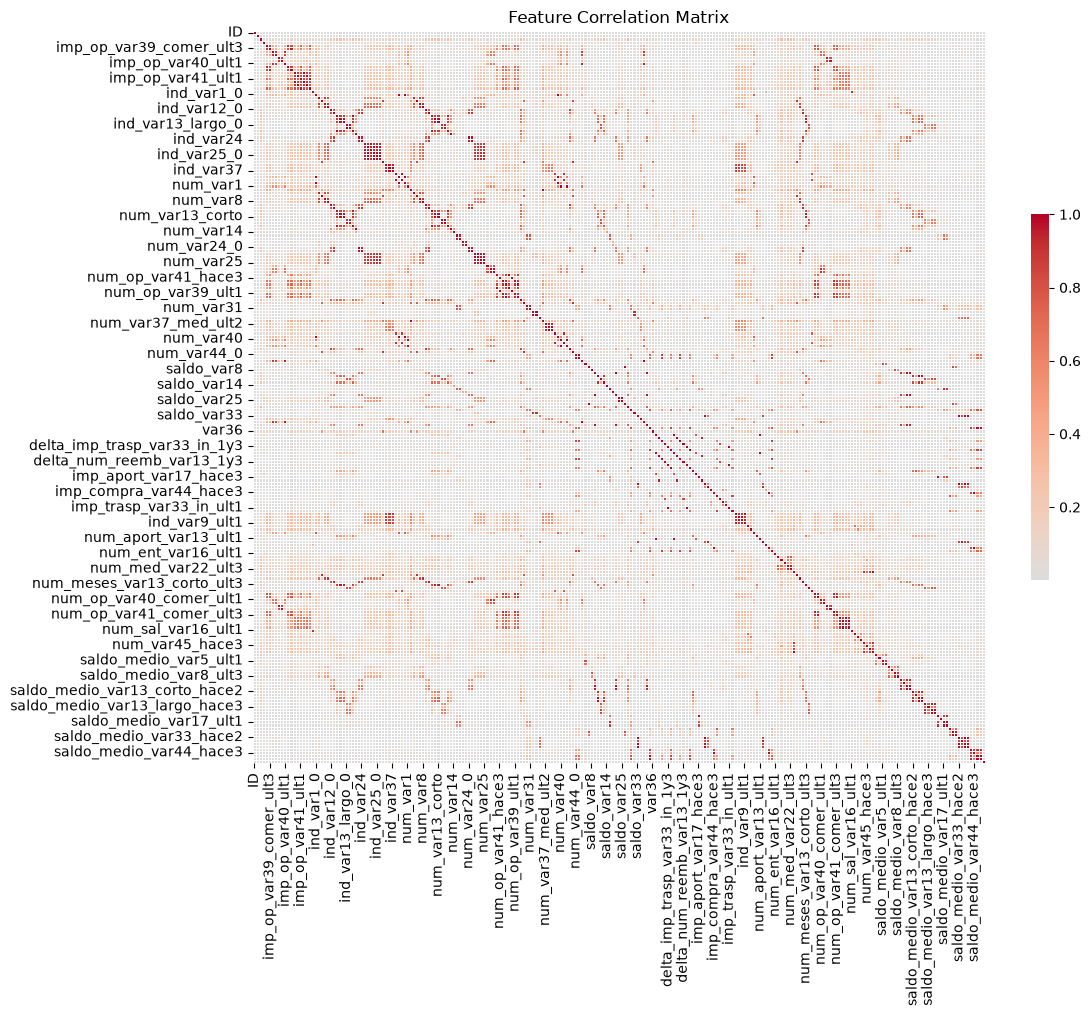

In [17]:
# ============================================
# 4. VISUALIZE CORRELATION MATRIX
# ============================================
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.5})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()